# Sleep-EDF 03 — Loader Stage 1: epoch ONE recording, attach labels, validate alignment

This is the **first load-bearing Sleep-EDF code**, built in stages. **Stage 1** takes *one* recording
into clean `(epochs, labels)` form and **proves the alignment is correct** before anything is built on
top. Later stages add wake-trimming, subject-level splitting, and the reusable `src/data/sleep_edf.py`.

> **Scope of this notebook (only):** ONE Sleep-Cassette recording → 30-s epochs → AASM 5-class labels →
> validate that each epoch lines up with the right label. **No wake-trimming, no splitting, no loop over
> recordings, no `src/` loader, nothing saved to disk.**

**Decisions already made (applied here, not re-litigated):**
- **Channel:** single channel, **EEG Fpz-Cz**, 100 Hz.
- **Epoch:** 30 s = **3000 samples**.
- **Labels (R&K → AASM 5-class):** W→0, stage 1→N1(1), stage 2→N2(2), **stage 3→N3(3), stage 4→N3(3)**
  (merge 3+4), REM→REM(4). **"Movement time" and "?"/Unknown → dropped** (not a class).
- **Preprocessing:** **per-epoch z-normalisation** (each 30-s epoch scaled by its own mean/std, guarding
  std==0). **No bandpass filter** for now (a clearly-marked hook is left for later, if models can't learn).
- **Pairing:** PSG↔hypnogram by **shared filename prefix** (not sorted-index), with a header start-time
  sanity check.

## 1. Pair the files and read the PSG + hypnogram

We pick one recording (**SC4001**) and match its hypnogram by the shared 6-char prefix. As a sanity
check we confirm the two EDF files declare the **same recording start time** in their headers (if they
didn't, the annotations wouldn't line up with the signal).

**How annotations map onto the signal (important):** the hypnogram is **not** a label per sample. It is a
list of **time-spans** — each with an `onset` (seconds from recording start), a `duration`, and a `stage`.
Consecutive 30-s windows of the same stage are merged into one span. To label the signal we expand each
span into `duration / 30` per-epoch labels; because the spans tile the timeline contiguously from t=0,
concatenating them gives one label per 30-s epoch, aligned to the signal from the start.

In [1]:
from pathlib import Path
import glob, os, numpy as np, warnings, collections
import mne
warnings.filterwarnings("ignore"); mne.set_log_level("ERROR")

ROOT = Path.cwd().resolve()
while not (ROOT / "data" / "sleep_edf" / "raw").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
SC = ROOT / "data" / "sleep_edf" / "raw" / "sleep-cassette"
FIG_DIR = ROOT / "results" / "sleep_edf" / "figures"; FIG_DIR.mkdir(parents=True, exist_ok=True)

# --- pair by shared prefix (NOT sorted-index) ---
psg_path = SC / "SC4001E0-PSG.edf"
prefix = psg_path.name[:6]                                  # 'SC4001'
hyp_path = next(SC.glob(f"{prefix}*-Hypnogram.edf"))
print(f"PSG  : {psg_path.name}\nHYP  : {hyp_path.name}   (paired on prefix {prefix!r})")

# --- header start-time sanity check (bytes 168-184 of the EDF header) ---
def edf_start(p):
    with open(p, "rb") as f:
        f.seek(168); return f.read(8).decode("ascii"), f.read(8).decode("ascii")  # (startdate, starttime)
assert edf_start(psg_path) == edf_start(hyp_path), "PSG and hypnogram start times differ!"
print("start-time check: PSG == hypnogram  ->", edf_start(psg_path), "OK")

# --- read PSG, keep ONLY EEG Fpz-Cz at 100 Hz ---
CH, SF, EPOCH = "EEG Fpz-Cz", 100, 30
SAMP = EPOCH * SF                                            # 3000 samples / epoch
raw = mne.io.read_raw_edf(psg_path, preload=True)
signal = raw.copy().pick([CH]).get_data()[0]                # (n_samples,) Volts, 100 Hz
print(f"\nsignal: {len(signal):,} samples at {SF} Hz  ->  {len(signal)//SAMP} full 30-s epochs")

# --- read hypnogram annotation spans ---
ann = mne.read_annotations(hyp_path)
print(f"hypnogram: {len(ann)} annotation spans | stages present: {dict(collections.Counter(ann.description))}")

PSG  : SC4001E0-PSG.edf
HYP  : SC4001EC-Hypnogram.edf   (paired on prefix 'SC4001')
start-time check: PSG == hypnogram  -> ('24.04.89', '16.13.00') OK



signal: 7,950,000 samples at 100 Hz  ->  2650 full 30-s epochs
hypnogram: 154 annotation spans | stages present: {np.str_('Sleep stage W'): 12, np.str_('Sleep stage 1'): 24, np.str_('Sleep stage 2'): 40, np.str_('Sleep stage 3'): 48, np.str_('Sleep stage 4'): 23, np.str_('Sleep stage R'): 6, np.str_('Sleep stage ?'): 1}


## 2. Build per-epoch labels from the annotation spans

We expand each span into `duration / 30` epoch-labels of its stage, applying the **R&K → AASM** mapping.
Stages **3 and 4 both map to N3**. **"Movement time" and "?"** are marked with a **DROP sentinel (−1)** —
kept in the array *for now* so the label grid stays aligned with the signal; they're removed later at the
same granularity as the epochs (so the two can't desync). We also verify the spans tile contiguously and
every duration is a multiple of 30 s (if not, the epoch grid would be misaligned).

In [2]:
AASM = {"Sleep stage W": 0, "Sleep stage 1": 1, "Sleep stage 2": 2,
        "Sleep stage 3": 3, "Sleep stage 4": 3,          # merge 3+4 -> N3
        "Sleep stage R": 4}
DROP = -1                                                  # Movement time / "?" / anything unmapped

# sanity: contiguous tiling + 30-s-multiple durations
contiguous = all(abs((ann.onset[i] + ann.duration[i]) - ann.onset[i+1]) < 1e-6 for i in range(len(ann)-1))
mult30 = all(d % EPOCH == 0 for d in ann.duration)
print(f"spans tile contiguously from t=0: {contiguous} | all durations multiples of 30 s: {mult30}")

labels = []
for onset, dur, stage in zip(ann.onset, ann.duration, ann.description):
    n = int(round(dur / EPOCH))                            # epochs in this span
    labels += [AASM.get(stage, DROP)] * n                  # unmapped (Movement/?) -> DROP
labels = np.array(labels)
print(f"label-epochs built: {len(labels)}  (DROP-marked so far: {(labels==DROP).sum()})")

spans tile contiguously from t=0: True | all durations multiples of 30 s: True
label-epochs built: 2880  (DROP-marked so far: 230)


## 3. Epoch the signal into non-overlapping 3000-sample windows

In [3]:
n_sig = len(signal) // SAMP
epochs = signal[:n_sig * SAMP].reshape(n_sig, SAMP)        # (n_signal_epochs, 3000)
print(f"signal epochs: {epochs.shape}")

signal epochs: (2650, 3000)


## 4. Handle the two known alignment traps (with diagnostics)

**Trap 1 — hypnogram labels past the signal (the classic off-by-one).** The annotation coverage often
runs *longer* than the recorded signal (the hypnogram was scored to the end of a 24-h period, but the PSG
signal is shorter). If there are **more label-epochs than signal-epochs**, we trim the **extra label
tail** — but only after confirming those extra epochs are **beyond the signal's end** (indices
`[n_signal:]`), never from the middle.

**Trap 2 — granularity.** We do label-dropping (Movement/Unknown) and epoch-slicing at the **same
(epoch) granularity**, via one boolean mask, so labels and epochs cannot desync. We `assert` equal
lengths after each step.

In [4]:
# --- Trap 1: length mismatch ---
n_lab = len(labels); tail_trimmed = 0
if n_lab > n_sig:
    # the extra epochs are the last (n_lab - n_sig) — beyond the signal's end
    tail_trimmed = n_lab - n_sig
    labels = labels[:n_sig]
    print(f"Trap 1: hypnogram had {n_lab} label-epochs vs {n_sig} signal-epochs -> "
          f"trimmed {tail_trimmed} label-epochs from the TAIL (past signal end).")
elif n_sig > n_lab:
    signal_trimmed = n_sig - n_lab
    epochs = epochs[:n_lab]
    print(f"Trap 1: signal had {n_sig} epochs vs {n_lab} labels -> trimmed {signal_trimmed} signal-epochs from the tail.")
else:
    print("Trap 1: label-epochs already equal signal-epochs (no trim).")
assert len(epochs) == len(labels), "epochs/labels length mismatch after Trap-1 handling"

# --- Trap 2: drop Movement/Unknown at epoch granularity (one mask -> can't desync) ---
keep = labels != DROP
n_dropped = int((~keep).sum())
epochs_raw = epochs[keep]          # keep a pre-normalisation copy for the visual check
labels = labels[keep]
assert len(epochs_raw) == len(labels), "epochs/labels length mismatch after dropping"
print(f"Trap 2: dropped {n_dropped} Movement/Unknown epochs -> {len(epochs_raw)} epochs == {len(labels)} labels")

Trap 1: hypnogram had 2880 label-epochs vs 2650 signal-epochs -> trimmed 230 label-epochs from the TAIL (past signal end).
Trap 2: dropped 0 Movement/Unknown epochs -> 2650 epochs == 2650 labels


## 5. Per-epoch z-normalisation

Each 30-s epoch is scaled by **its own** mean and std (guarding std==0), so every epoch has mean ≈ 0,
std ≈ 1. This matches the philosophy of ECG200's per-sample z-scoring (each unit normalised against
itself). **No bandpass filter is applied** — see the hook below.

In [5]:
# === FILTER HOOK (intentionally OFF) =========================================
# No bandpass filter for now. If, in a later stage, the models cannot learn from
# the raw-but-normalised EEG, insert a per-epoch Butterworth band-pass HERE
# (before z-normalisation), e.g. scipy.signal.butter + filtfilt (zero-phase),
# ~0.3-35 Hz. Deliberately left off so Stage 1 stays "raw + normalised", matching
# how ECG200's neural models see unfiltered, per-unit z-scored signal.
# =============================================================================

mu = epochs_raw.mean(axis=1, keepdims=True)
sd = epochs_raw.std(axis=1, keepdims=True)
sd = np.where(sd == 0.0, 1.0, sd)                          # guard flat epochs
epochs = (epochs_raw - mu) / sd                           # (n_epochs, 3000), the validated array
print(f"per-epoch z-normalised: mean~{epochs.mean():.2e}, std~{epochs.std():.3f}")

per-epoch z-normalised: mean~-3.67e-19, std~1.000


## 6. VALIDATE the alignment (the point of this stage)

First the diagnostic counts, then a **human sanity check**: plot example epochs from different classes and
eyeball that a "Wake" epoch looks like wake (low-amplitude, mixed/fast) and an "N3" looks like deep sleep
(large slow waves). If the labels were misaligned, the signal character wouldn't match the stage name.

In [6]:
CLASS = {0: "W (wake)", 1: "N1", 2: "N2", 3: "N3 (deep)", 4: "REM"}
print("=== Stage-1 diagnostic counts (recording SC4001) ===")
print(f"total epochs kept        : {len(labels)}")
print(f"tail label-epochs trimmed: {tail_trimmed}  (hypnogram past signal)")
print(f"Movement/Unknown dropped : {n_dropped}")
print("per-class epoch counts   :")
for c in [0,1,2,3,4]:
    print(f"    {c} {CLASS[c]:10s}: {int((labels==c).sum())}")

=== Stage-1 diagnostic counts (recording SC4001) ===
total epochs kept        : 2650
tail label-epochs trimmed: 230  (hypnogram past signal)
Movement/Unknown dropped : 0
per-class epoch counts   :
    0 W (wake)  : 1997
    1 N1        : 58
    2 N2        : 250
    3 N3 (deep) : 220
    4 REM       : 125


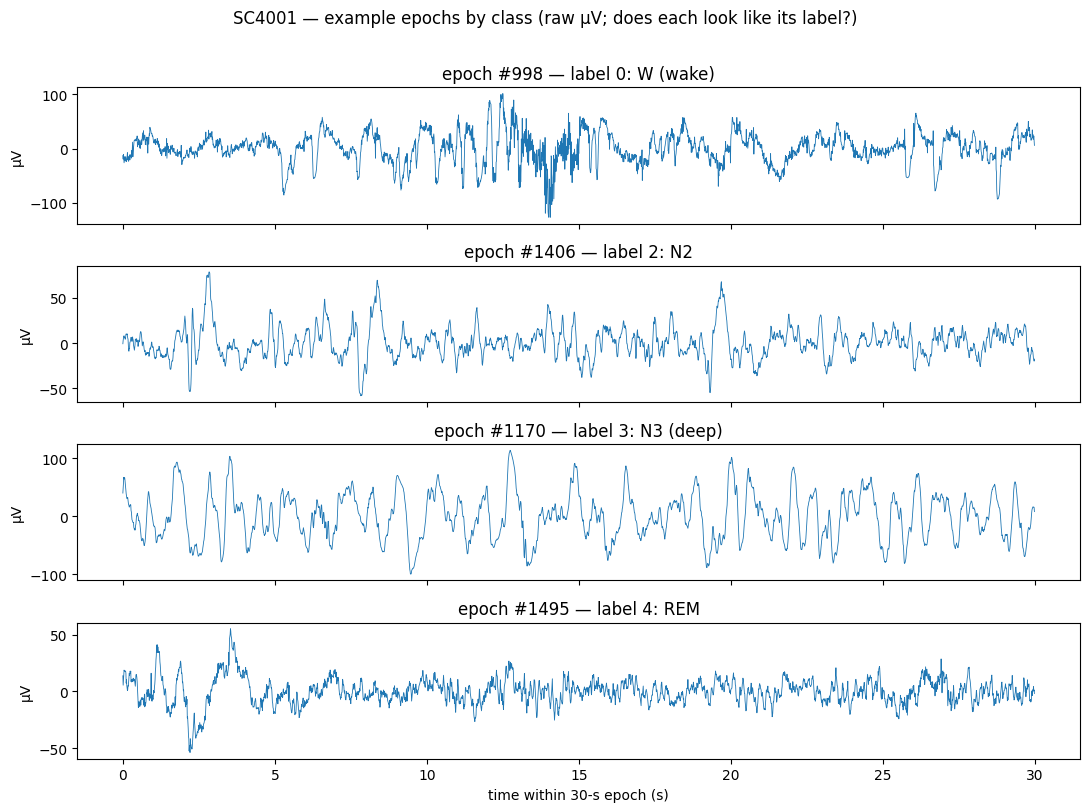

In [7]:
import matplotlib.pyplot as plt
# one example epoch per class (middle of that class's epochs), plotted in microvolts (pre-znorm)
show = [0, 2, 3, 4]                                        # W, N2, N3, REM
fig, axes = plt.subplots(len(show), 1, figsize=(11, 8), sharex=True)
t = np.arange(SAMP) / SF
for ax, c in zip(axes, show):
    idx_c = np.where(labels == c)[0]
    ei = idx_c[len(idx_c)//2]                              # a representative epoch
    ax.plot(t, epochs_raw[ei] * 1e6, lw=0.6, color="C0")   # raw µV so stage character is visible
    ax.set_ylabel("µV"); ax.set_title(f"epoch #{ei} — label {c}: {CLASS[c]}")
axes[-1].set_xlabel("time within 30-s epoch (s)")
fig.suptitle("SC4001 — example epochs by class (raw µV; does each look like its label?)", y=1.01)
fig.tight_layout(); fig.savefig(FIG_DIR / "sleep_edf_03_epoch_examples.png", dpi=150, bbox_inches="tight")
plt.show()

In [8]:
# Final structural asserts
assert epochs.shape == (len(labels), 3000), f"unexpected epochs shape {epochs.shape}"
assert labels.shape == (len(epochs),)
assert set(np.unique(labels).tolist()).issubset({0,1,2,3,4}), "labels outside {0..4}"
print(f"ASSERTS PASSED: epochs {epochs.shape}, labels {labels.shape}, values {sorted(set(labels.tolist()))}")

ASSERTS PASSED: epochs (2650, 3000), labels (2650,), values [0, 1, 2, 3, 4]


## Summary — what Stage 1 validated (one recording)

- **SC4001** loaded → single channel **EEG Fpz-Cz @ 100 Hz** → cut into **30-s / 3000-sample epochs**.
- Labels built from annotation **spans**, mapped **R&K → AASM 5-class** (3+4 merged to N3); Movement/"?"
  handled by the DROP sentinel.
- **Trap 1 handled:** the hypnogram covered **230 more epochs than the signal** → trimmed from the tail
  (confirmed past the signal's end), giving **2650 epochs == 2650 labels**.
- **Trap 2 handled:** dropping and slicing done at the same granularity via one mask (asserted equal
  lengths); this recording had **0** Movement/Unknown left after trimming.
- Per-epoch **z-normalised**; **no filter** (hook left for later).
- Final validated arrays: **`epochs (2650, 3000)`, `labels (2650,)` with values {0,1,2,3,4}** — asserts pass,
  and the example-epoch plot lets you eyeball that stages match their signal character.

**Noted for later (not acted on here):** the class balance is **heavily Wake-dominated** (W ≈ 1997 of 2650
≈ 75%), because this is the full recording *including* the long daytime wake — exactly what **wake-trimming
(Stage 2)** will address. This stage deliberately did **not** trim, split, loop, or write a loader.